In [1]:
%matplotlib inline
from pathlib import Path
import json
import sys

ROOT = Path.cwd()
if ROOT.name == 'notebook':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from medmas.eda_image.paths import resolve_paths
from medmas.eda_image.metadata import add_metadata_features, compute_integrity_summary, load_metadata, AGE_BIN_LABELS
from medmas.eda_image.labels import (
    build_multi_hot,
    compute_age_bin_prevalence,
    compute_binary_group_risk,
    compute_cooccurrence,
    compute_label_summary,
    compute_labelset_summary,
    compute_multilabel_summary,
    compute_pairwise_associations,
    get_all_labels,
)
from medmas.eda_image.splits import compute_patient_dynamics, simulate_split_leakage
from medmas.eda_image.image_quality import (
    QUALITY_COLS,
    compute_or_load_image_metrics,
    compute_rgba_consistency,
    summarize_ahash_collisions,
)
from medmas.eda_image.plots import (
    apply_plot_style,
    plot_heatmap,
    plot_horizontal_risk_ratio,
    plot_image_grid,
    plot_label_frequency,
)

apply_plot_style()
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 160)

paths = resolve_paths(ROOT)
paths.artifacts_dir.mkdir(parents=True, exist_ok=True)

df_raw = load_metadata(paths.csv_path)
df = add_metadata_features(df_raw)
all_labels = get_all_labels(df)
multi_hot = build_multi_hot(df, all_labels)
label_summary = compute_label_summary(multi_hot)

data_source = pd.DataFrame([
    ('project_root', str(paths.root)),
    ('csv_path', str(paths.csv_path)),
    ('image_dir', str(paths.image_dir)),
    ('artifacts_dir', str(paths.artifacts_dir)),
    ('baseline_path', str(paths.baseline_path)),
    ('image_metrics_cache', str(paths.image_metrics_path)),
])
data_source.columns = ['item', 'value']
display(data_source)


,item,value
0,project_root,/home/dodaonam/Projects/MedMAS
1,csv_path,/home/dodaonam/Projects/MedMAS/data/chest_x-ra...
2,image_dir,/home/dodaonam/Projects/MedMAS/data/chest_x-ra...
3,artifacts_dir,/home/dodaonam/Projects/MedMAS/artifacts/eda_i...
4,baseline_path,/home/dodaonam/Projects/MedMAS/artifacts/eda_i...
5,image_metrics_cache,/home/dodaonam/Projects/MedMAS/artifacts/eda_i...


**Diễn giải:** Toàn bộ kết luận bên dưới dùng các path hiển thị trong bảng này. Nếu source path thay đổi, các cell sau phải được chạy lại để tạo bằng chứng mới.


## 1. Dataset integrity

**Câu hỏi:** CSV và ảnh trên disk có khớp nhau không, có missing/duplicate cơ bản không?


,metric,value
0,rows_csv,5606
1,cols_csv,11
2,unique_images_csv,5606
3,images_on_disk,5606
4,missing_values_total,0
5,duplicated_rows,0
6,csv_images_not_in_disk,0
7,disk_images_not_in_csv,0


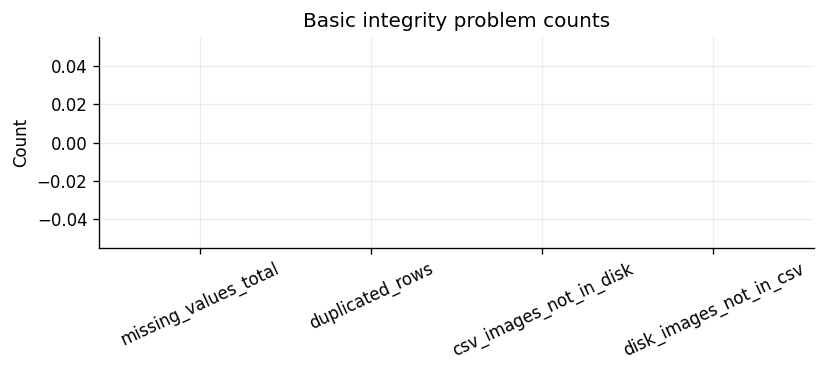

In [2]:
integrity = compute_integrity_summary(df_raw, paths.image_dir)
display(integrity)

fig, ax = plt.subplots(figsize=(7, 3.2))
check_df = integrity[integrity['metric'].isin(['csv_images_not_in_disk', 'disk_images_not_in_csv', 'missing_values_total', 'duplicated_rows'])]
ax.bar(check_df['metric'], check_df['value'].astype(int), color='#0f766e')
ax.set_title('Basic integrity problem counts')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()


**Diễn giải:** Dataset sạch ở mức integrity cơ bản: không có missing, duplicate row, hoặc mismatch CSV-vs-disk. Đây là điều kiện tối thiểu để các phân tích prevalence và image-quality bên dưới có ý nghĩa.


## 2. Sample image preview

**Câu hỏi:** ảnh local load được và trông như ảnh X-quang ngực đúng kỳ vọng không?


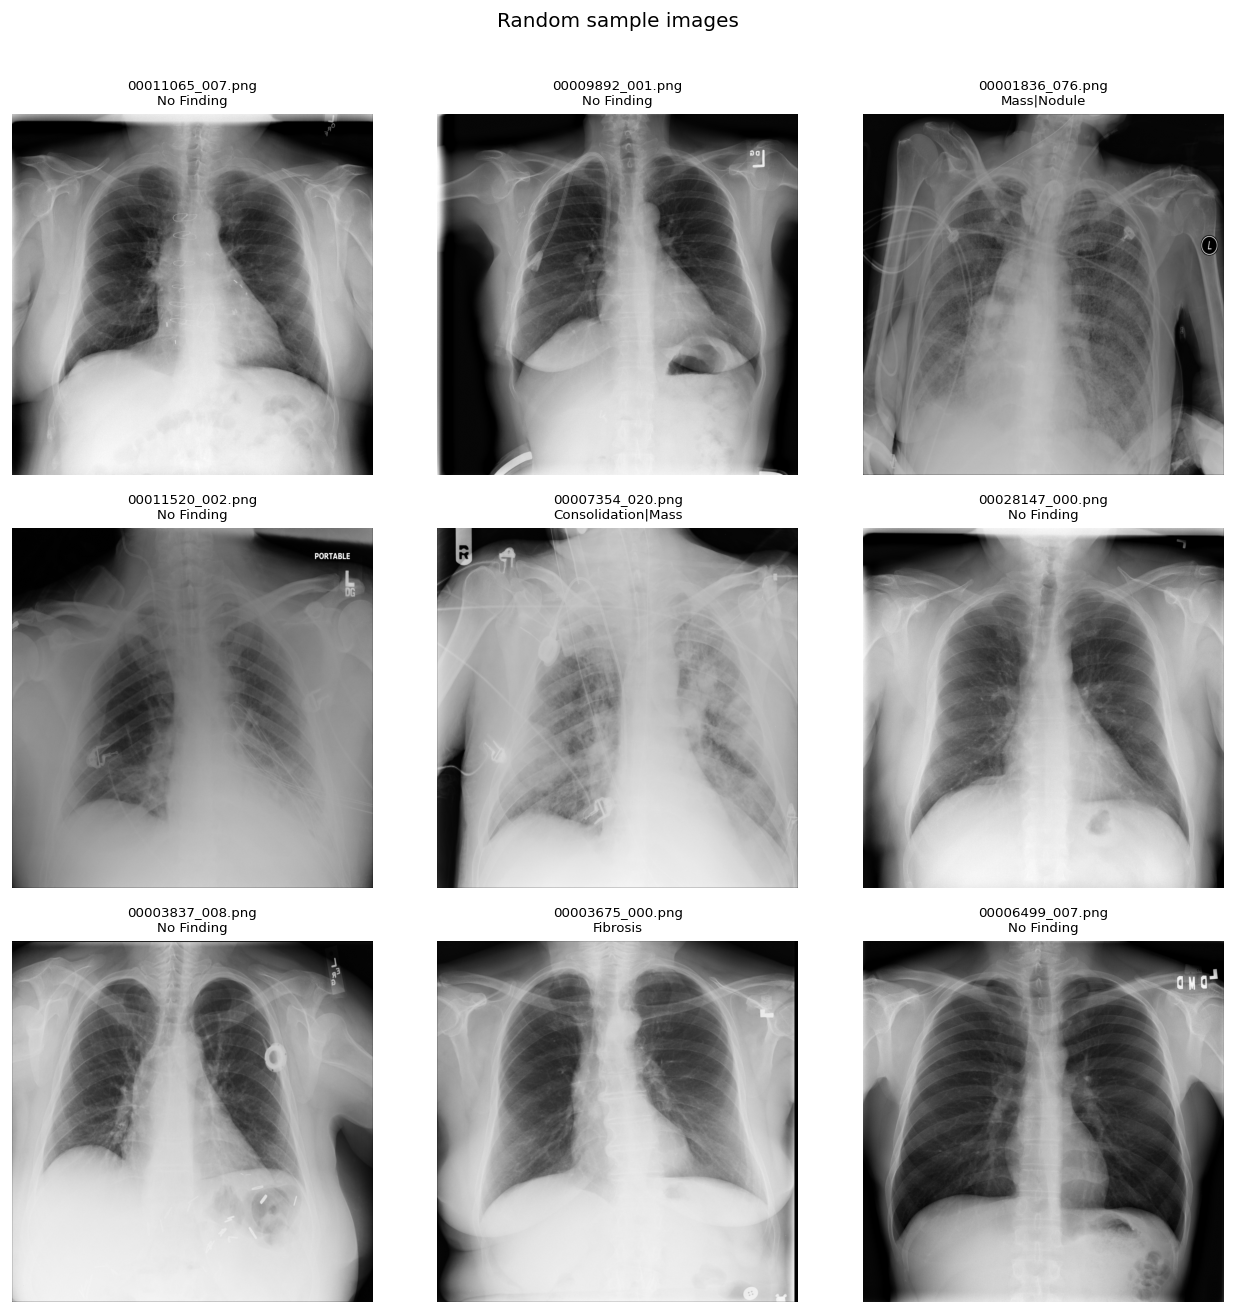

In [3]:
sample_rows = df.sample(9, random_state=42).reset_index(drop=True)
plot_image_grid(sample_rows, paths.image_dir, ['Image Index', 'Finding Labels'], n_cols=3, suptitle='Random sample images')
plt.show()


**Diễn giải:** Preview trực quan xác nhận ảnh có thể load và hiển thị từ image directory đã chọn. Các title giữ `Image Index` và label để mỗi ví dụ đều trace được về metadata.


## 3. Metadata và acquisition

**Câu hỏi:** giới tính, view position, tuổi và metadata acquisition có phân bố như thế nào?


,gender_count,view_count
M,3134.0,NaN
F,2472.0,NaN
PA,NaN,3393.0
AP,NaN,2213.0


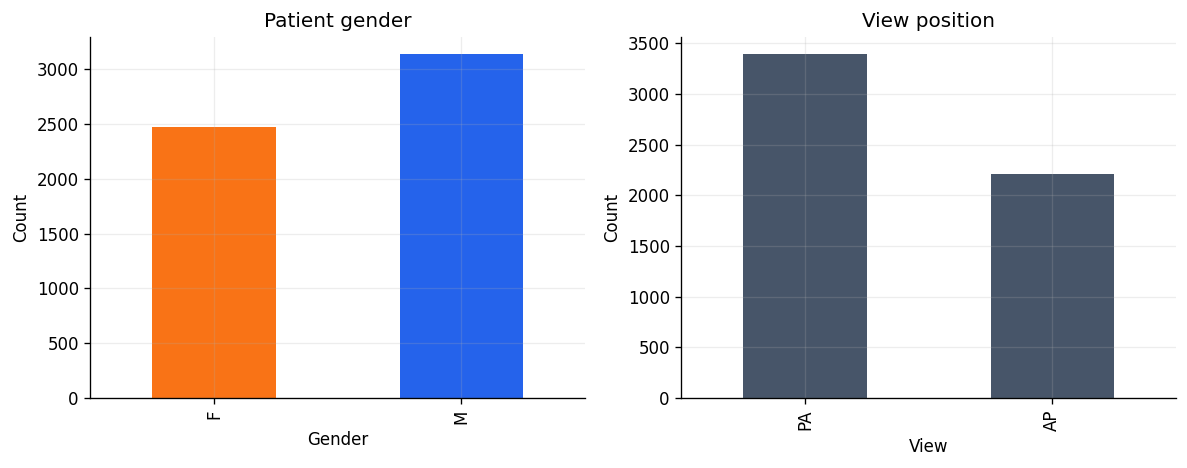

In [4]:
gender_view = pd.concat([
    df['Patient Gender'].value_counts().rename('gender_count'),
    df['View Position'].value_counts().rename('view_count'),
], axis=1)
display(gender_view)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df['Patient Gender'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color=['#f97316', '#2563eb'])
axes[0].set_title('Patient gender')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Count')
df['View Position'].value_counts().plot(kind='bar', ax=axes[1], color='#475569')
axes[1].set_title('View position')
axes[1].set_xlabel('View')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.show()


,count
AgeUnit,
Y,5604
M,1
D,1


,AgeYears
count,5606.000000
mean,46.767764
std,17.412761
min,0.002740
1%,7.000000
5%,17.000000
25%,35.000000
50%,49.000000
75%,59.000000
95%,71.000000


,Image Index,Patient ID,Patient Age,AgeYears,Finding Labels
4242,00020900_002.png,20900,411Y,411.0,No Finding


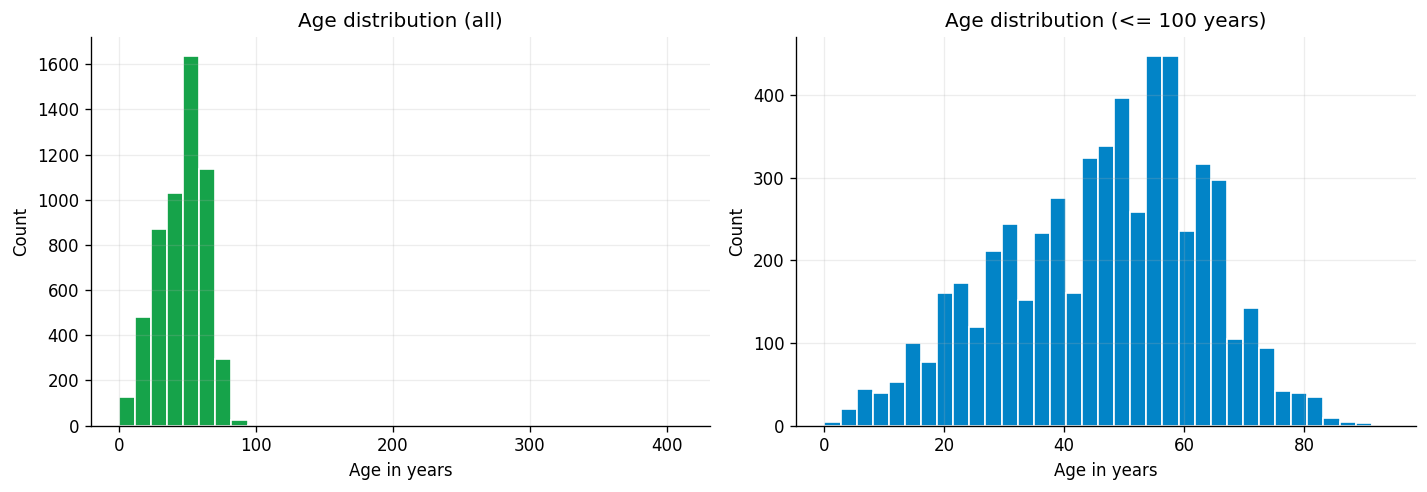

In [5]:
age_summary = df['AgeYears'].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).to_frame('AgeYears')
age_units = df['AgeUnit'].value_counts(dropna=False).to_frame('count')
age_outliers = df.loc[df['AgeYears'] > 100, ['Image Index', 'Patient ID', 'Patient Age', 'AgeYears', 'Finding Labels']]

display(age_units)
display(age_summary)
display(age_outliers)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].hist(df['AgeYears'].dropna(), bins=35, color='#16a34a', edgecolor='white')
axes[0].set_title('Age distribution (all)')
axes[0].set_xlabel('Age in years')
axes[0].set_ylabel('Count')
axes[1].hist(df.loc[df['AgeYears'] <= 100, 'AgeYears'].dropna(), bins=35, color='#0284c7', edgecolor='white')
axes[1].set_title('Age distribution (<= 100 years)')
axes[1].set_xlabel('Age in years')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.show()


,count
OriginalResolution,
2500x2048,1786
2992x2991,1088
3056x2544,803
2048x2500,471
2021x2021,203
2544x3056,125
2020x2021,17
2990x2991,16
2986x2991,12


View Position,AP,PA,total
OriginalResolution,,,
2500x2048,1324,462,1786
2992x2991,0,1088,1088
3056x2544,705,98,803
2048x2500,95,376,471
2021x2021,0,203,203
2544x3056,24,101,125
2020x2021,0,17,17
2990x2991,0,16,16
2986x2991,0,12,12


,OriginalImagePixelSpacing_x,OriginalImagePixelSpacing_y
View Position,,
AP,0.158019,0.158019
PA,0.153802,0.153802


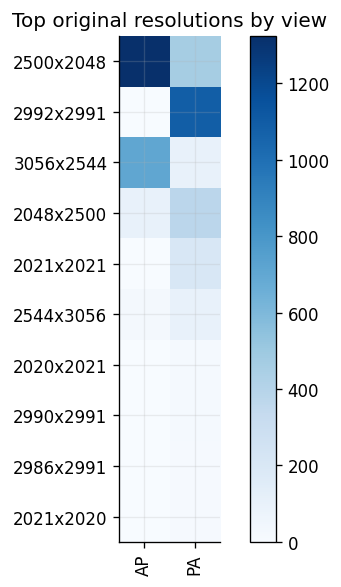

In [6]:
resolution_counts = df['OriginalResolution'].value_counts().head(12).to_frame('count')
resolution_view = pd.crosstab(df['OriginalResolution'], df['View Position'])
resolution_view['total'] = resolution_view.sum(axis=1)
resolution_view_top = resolution_view.sort_values('total', ascending=False).head(10)
spacing_by_view = df.groupby('View Position')[['OriginalImagePixelSpacing_x', 'OriginalImagePixelSpacing_y']].mean()

display(resolution_counts)
display(resolution_view_top)
display(spacing_by_view)

plot_heatmap(resolution_view_top[['AP', 'PA']], 'Top original resolutions by view', cmap='Blues', figsize=(7, 5))
plt.show()


**Diễn giải:** View `PA` nhiều hơn `AP`, tuổi có một outlier metadata rõ (`411Y`), và resolution gốc liên hệ mạnh với view. Vì view/resolution có thể là proxy acquisition, các phân tích model sau này cần AP/PA-aware evaluation.


## 4. Label landscape

**Câu hỏi:** các label phổ biến/hiếm thế nào, và bài toán multi-label dày đến mức nào?


,count,prevalence_pct
No Finding,3044,54.298965
Infiltration,967,17.249376
Effusion,644,11.487692
Atelectasis,508,9.061720
Nodule,313,5.583304
Mass,284,5.066001
Pneumothorax,271,4.834106
Consolidation,226,4.031395
Pleural_Thickening,176,3.139493
Cardiomegaly,141,2.515162


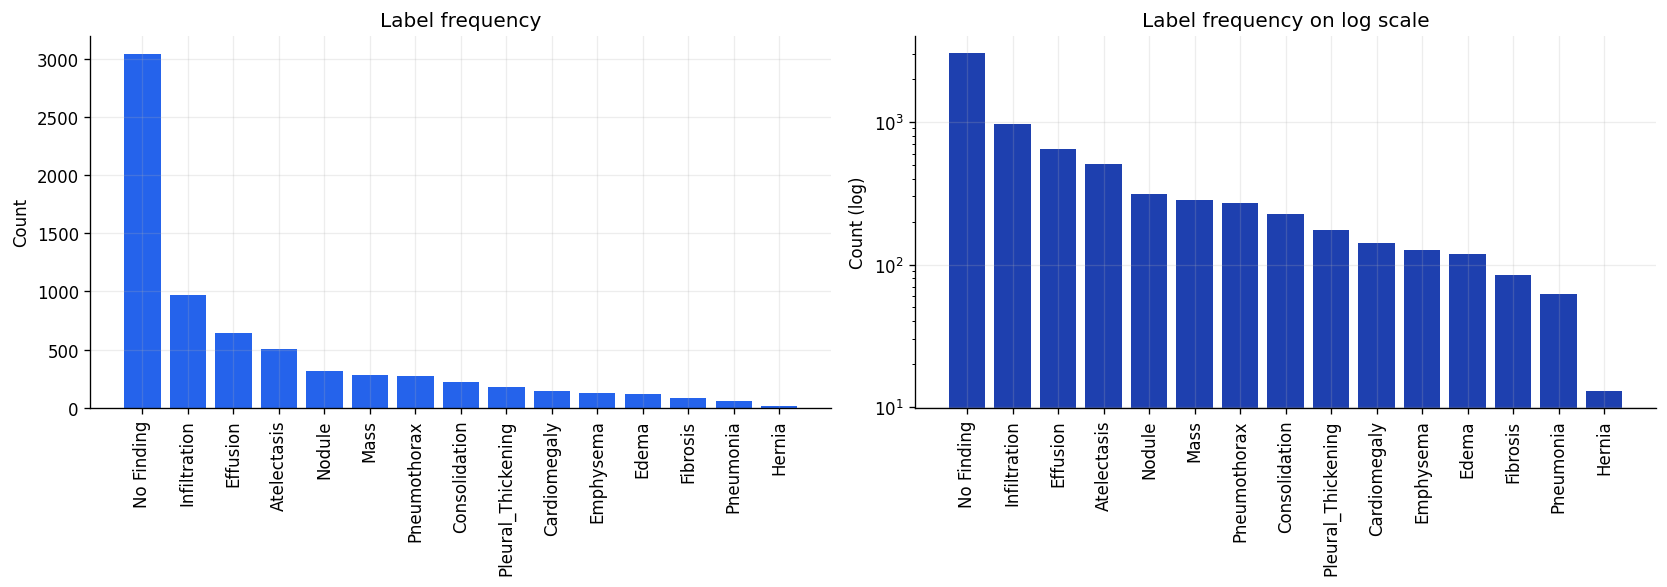

,metric,value
0,num_classes,15.000000
1,imbalance_ratio_max_min,234.153846
2,rare_labels_count_le_100,3.000000


,count,prevalence_pct
Fibrosis,84,1.498395
Pneumonia,62,1.105958
Hernia,13,0.231894


In [7]:
display(label_summary)
plot_label_frequency(label_summary)
plt.show()

imbalance_ratio = label_summary['count'].max() / label_summary['count'].min()
rare_labels = label_summary[label_summary['count'] <= 100]
label_context = pd.DataFrame([
    ('num_classes', len(all_labels)),
    ('imbalance_ratio_max_min', imbalance_ratio),
    ('rare_labels_count_le_100', len(rare_labels)),
], columns=['metric', 'value'])
display(label_context)
display(rare_labels)


,metric,value
0,label_cardinality,1.244738
1,label_density,0.082983
2,unique_labelsets,244.000000
3,multi_label_ratio_pct,17.481270


,count
NumLabels,
1,4626
2,690
3,212
4,58
5,17
6,2
7,1


,count
Finding Labels,
No Finding,3044
Infiltration,503
Effusion,203
Atelectasis,192
Nodule,144
Pneumothorax,114
Mass,99
Consolidation,72
Effusion|Infiltration,69


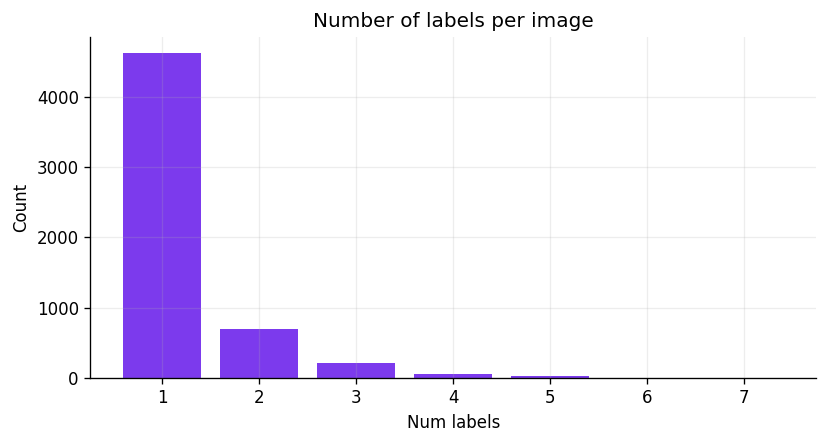

In [8]:
multilabel_summary = compute_multilabel_summary(df, len(all_labels))
num_label_dist = df['NumLabels'].value_counts().sort_index().to_frame('count')
labelset_top = compute_labelset_summary(df, top_n=20)

display(multilabel_summary)
display(num_label_dist)
display(labelset_top)

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.bar(num_label_dist.index.astype(str), num_label_dist['count'], color='#7c3aed')
ax.set_title('Number of labels per image')
ax.set_xlabel('Num labels')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()


**Diễn giải:** `No Finding` áp đảo, trong khi các nhãn như `Hernia`, `Pneumonia`, `Fibrosis` rất hiếm. Accuracy tổng thể sẽ dễ gây ảo tưởng; evaluation cần per-class metrics và PR-AUC cho lớp hiếm.


## 5. Co-occurrence

**Câu hỏi:** các bệnh đồng xuất hiện với nhau theo pattern nào?


,Atelectasis,Cardiomegaly,Consolidation,Edema,Effusion,Emphysema,Fibrosis,Hernia,Infiltration,Mass,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax
Atelectasis,252,15,56,11,151,20,13,5,130,26,25,20,11,32
Cardiomegaly,15,141,11,8,57,4,4,0,25,6,4,4,3,2
Consolidation,56,11,226,8,63,4,4,0,57,28,14,14,12,12
Edema,11,8,8,118,25,1,1,0,46,5,4,0,14,1
Effusion,151,57,63,25,132,24,12,2,173,54,46,38,8,52
Emphysema,20,4,4,1,24,127,3,0,20,13,5,8,3,34
Fibrosis,13,4,4,1,12,3,84,1,14,6,5,9,0,2
Hernia,5,0,0,0,2,0,1,13,2,3,0,0,0,1
Infiltration,130,25,57,46,173,20,14,2,199,54,75,33,23,42
Mass,26,6,28,5,54,13,6,3,54,28,44,23,4,34


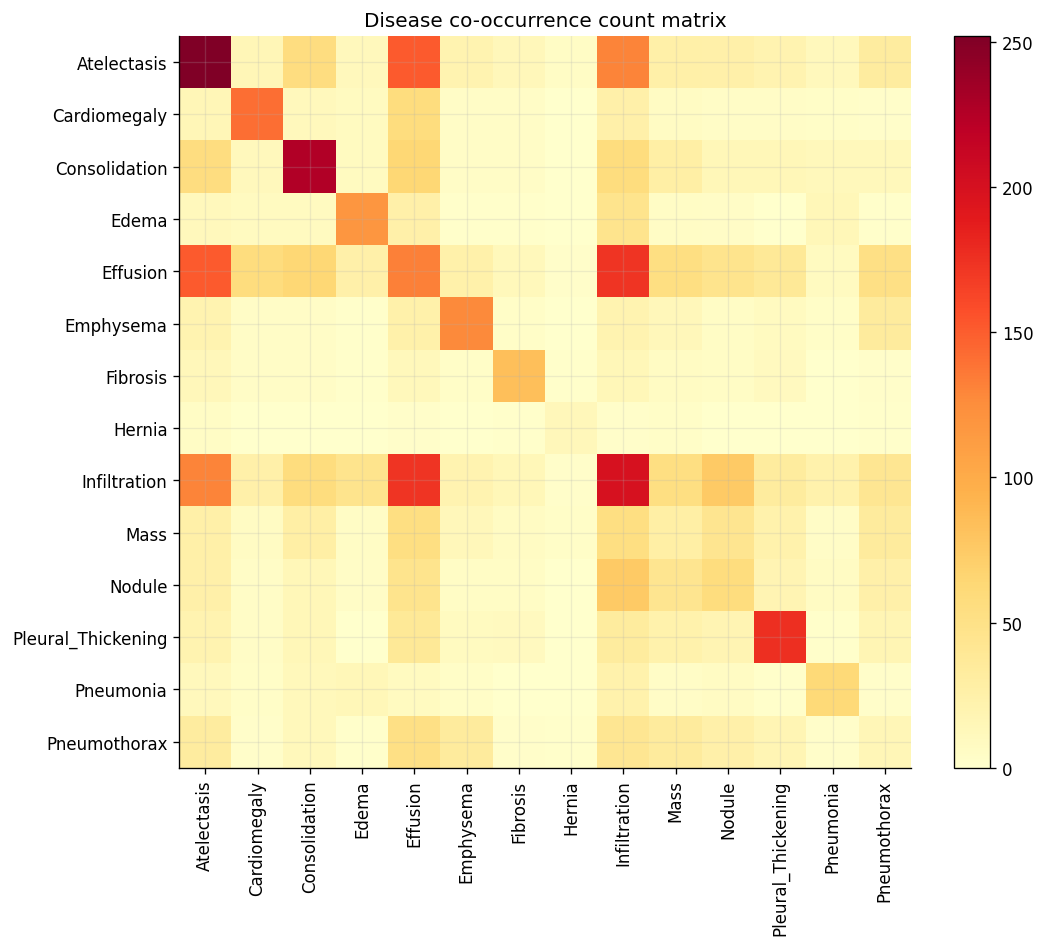

In [9]:
co_count = compute_cooccurrence(multi_hot)
display(co_count)
plot_heatmap(co_count, 'Disease co-occurrence count matrix', cmap='YlOrRd', figsize=(10, 8))
plt.show()


In [10]:
pairs_df = compute_pairwise_associations(multi_hot)
top_co = pairs_df.sort_values('co_count', ascending=False).head(15)
top_jaccard = pairs_df[(pairs_df['support_a'] >= 20) & (pairs_df['support_b'] >= 20)].sort_values('jaccard', ascending=False).head(15)
top_lift = pairs_df[(pairs_df['support_a'] >= 40) & (pairs_df['support_b'] >= 40)].sort_values('lift', ascending=False).head(15)

display(top_co)
display(top_jaccard)
display(top_lift)


,label_a,label_b,co_count,jaccard,lift,support_a,support_b
45,Effusion,Infiltration,173,0.120306,1.557352,644,967
3,Atelectasis,Effusion,151,0.150849,2.587501,508,644
7,Atelectasis,Infiltration,130,0.096654,1.483564,508,967
68,Infiltration,Nodule,75,0.062241,1.389132,967,313
25,Consolidation,Effusion,63,0.078067,2.426606,226,644
15,Cardiomegaly,Effusion,57,0.078297,3.519030,141,644
28,Consolidation,Infiltration,57,0.050176,1.462154,226,967
1,Atelectasis,Consolidation,56,0.082596,2.734444,508,226
46,Effusion,Mass,54,0.061785,1.655170,644,284
67,Infiltration,Mass,54,0.045113,1.102306,967,284


,label_a,label_b,co_count,jaccard,lift,support_a,support_b
3,Atelectasis,Effusion,151,0.150849,2.587501,508,644
45,Effusion,Infiltration,173,0.120306,1.557352,644,967
7,Atelectasis,Infiltration,130,0.096654,1.483564,508,967
57,Emphysema,Pneumothorax,34,0.093407,5.538077,127,271
40,Edema,Pneumonia,14,0.084337,10.727720,118,62
1,Atelectasis,Consolidation,56,0.082596,2.734444,508,226
72,Mass,Nodule,44,0.079566,2.774873,284,313
15,Cardiomegaly,Effusion,57,0.078297,3.519030,141,644
25,Consolidation,Effusion,63,0.078067,2.426606,226,644
75,Mass,Pneumothorax,34,0.065259,2.476534,284,271


,label_a,label_b,co_count,jaccard,lift,support_a,support_b
40,Edema,Pneumonia,14,0.084337,10.727720,118,62
57,Emphysema,Pneumothorax,34,0.093407,5.538077,127,271
32,Consolidation,Pneumonia,12,0.043478,4.801028,226,62
15,Cardiomegaly,Effusion,57,0.078297,3.519030,141,644
62,Fibrosis,Pleural_Thickening,9,0.035857,3.412744,84,176
72,Mass,Nodule,44,0.079566,2.774873,284,313
1,Atelectasis,Consolidation,56,0.082596,2.734444,508,226
14,Cardiomegaly,Edema,8,0.031873,2.695516,141,118
3,Atelectasis,Effusion,151,0.150849,2.587501,508,644
73,Mass,Pleural_Thickening,23,0.052632,2.579585,284,176


**Diễn giải:** Một số cụm bệnh có đồng xuất hiện rõ như Effusion/Infiltration/Atelectasis. Các cặp lift cao nhưng support thấp cần được diễn giải thận trọng, không nên xem là bằng chứng chắc chắn nếu chưa kiểm thêm trên full dataset/split khác.


## 6. Confounding theo view, giới và tuổi

**Câu hỏi:** prevalence label có lệch theo AP/PA, gender hoặc age-bin không?


,label,AP_cases,PA_cases,AP_prev,PA_prev,risk_ratio_AP_over_PA,log2_rr
3,Edema,106,12,0.047899,0.003537,13.543380,3.759516
2,Consolidation,147,79,0.066426,0.023283,2.852940,1.512450
13,Pneumonia,38,24,0.017171,0.007073,2.427587,1.279523
8,Infiltration,503,464,0.227293,0.136752,1.662082,0.732992
0,Atelectasis,257,251,0.116132,0.073976,1.569863,0.650639
4,Effusion,308,336,0.139178,0.099027,1.405445,0.491027
1,Cardiomegaly,64,77,0.028920,0.022694,1.274359,0.349771
5,Emphysema,45,82,0.020334,0.024167,0.841397,-0.249141
14,Pneumothorax,95,176,0.042928,0.051872,0.827586,-0.273018
10,No Finding,1057,1987,0.477632,0.585617,0.815604,-0.294059


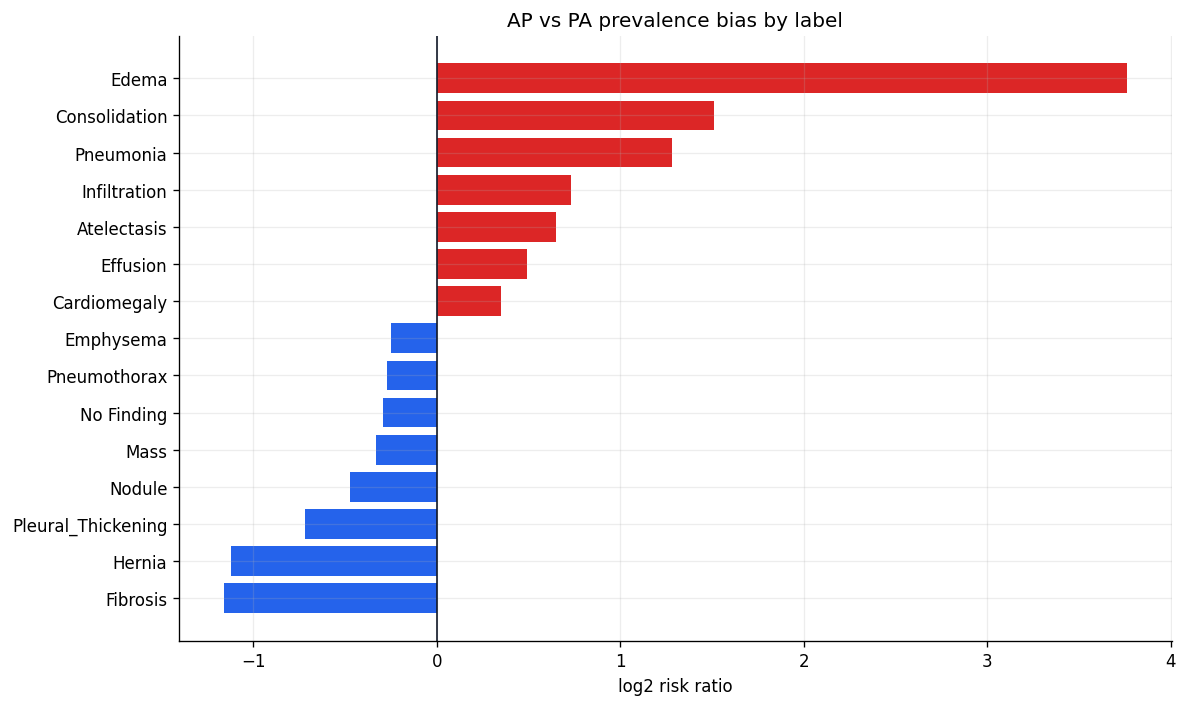

In [11]:
view_bias = compute_binary_group_risk(df, multi_hot, 'View Position', 'AP', 'PA')
display(view_bias)
plot_horizontal_risk_ratio(view_bias, title='AP vs PA prevalence bias by label')
plt.show()


,label,M_cases,F_cases,M_prev,F_prev,risk_ratio_M_over_F,log2_rr
0,Atelectasis,321,187,0.102425,0.075647,1.353982,0.437209
5,Emphysema,76,51,0.024250,0.020631,1.175419,0.233176
9,Mass,169,115,0.053925,0.046521,1.159147,0.213063
4,Effusion,370,274,0.118060,0.110841,1.065125,0.091023
8,Infiltration,545,422,0.173899,0.170712,1.018670,0.026687
10,No Finding,1701,1343,0.542757,0.543285,0.999028,-0.001403
12,Pleural_Thickening,98,78,0.031270,0.031553,0.991017,-0.013019
11,Nodule,173,140,0.055201,0.056634,0.974692,-0.036981
2,Consolidation,124,102,0.039566,0.041262,0.958895,-0.060555
7,Hernia,7,6,0.002234,0.002427,0.920230,-0.119934


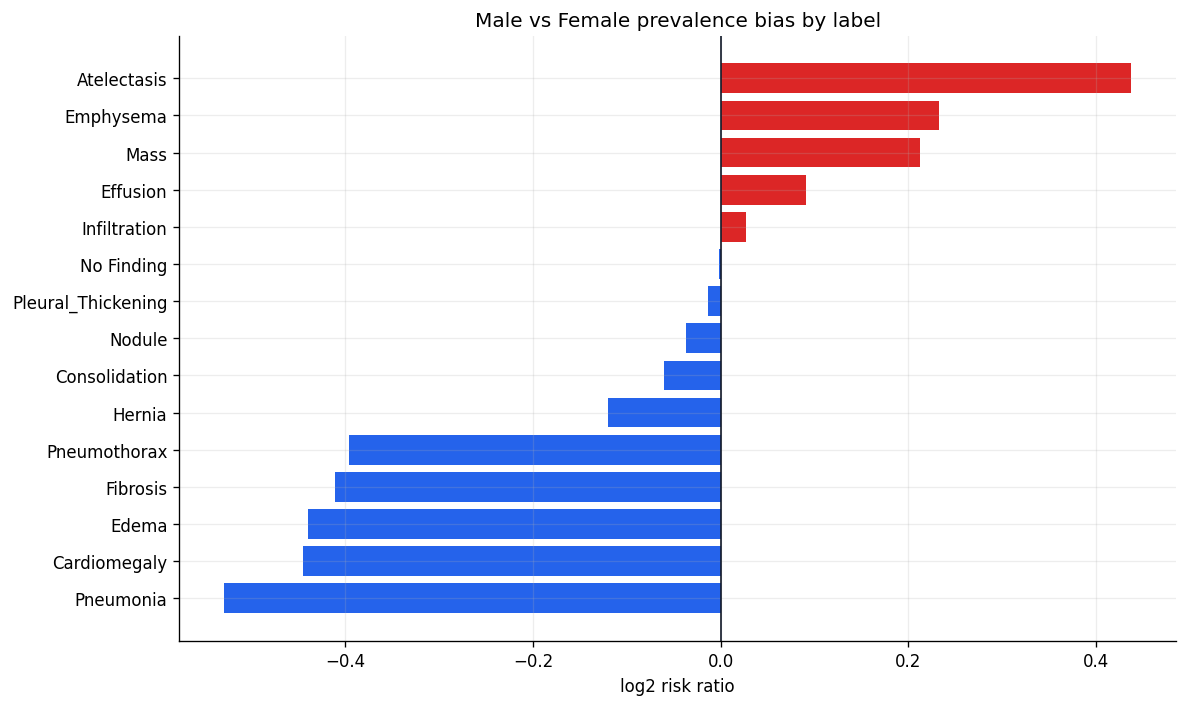

In [12]:
gender_bias = compute_binary_group_risk(df, multi_hot, 'Patient Gender', 'M', 'F')
display(gender_bias.sort_values('log2_rr', ascending=False))
plot_horizontal_risk_ratio(gender_bias, title='Male vs Female prevalence bias by label')
plt.show()


,count
AgeBin,
41-60,2492
19-40,1570
61-80,1153
0-18,338
81-150,52
150+,1


AgeBin,0-18,150+,19-40,41-60,61-80,81-150
Label,,,,,,
Atelectasis,0.041,0.0,0.062,0.107,0.108,0.096
Cardiomegaly,0.033,0.0,0.025,0.022,0.026,0.096
Consolidation,0.047,0.0,0.036,0.038,0.049,0.019
Edema,0.036,0.0,0.023,0.019,0.019,0.000
Effusion,0.086,0.0,0.092,0.118,0.144,0.192
Emphysema,0.012,0.0,0.016,0.022,0.037,0.019
Fibrosis,0.003,0.0,0.011,0.013,0.027,0.038
Hernia,0.000,0.0,0.001,0.002,0.005,0.019
Infiltration,0.192,0.0,0.171,0.168,0.177,0.192


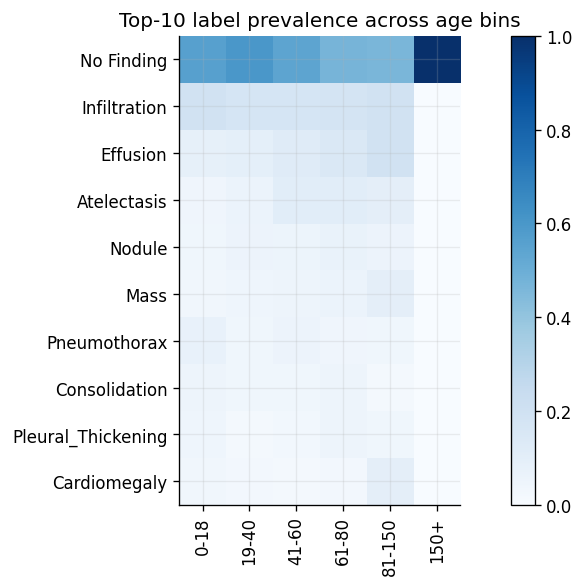

In [13]:
age_prev = compute_age_bin_prevalence(df, all_labels)
age_heat = age_prev.pivot(index='Label', columns='AgeBin', values='prevalence').fillna(0)
age_counts = df['AgeBin'].value_counts(dropna=False).to_frame('count')
top10_labels = label_summary.head(10).index.tolist()

display(age_counts)
display(age_heat.round(3))
plot_heatmap(age_heat.loc[top10_labels, AGE_BIN_LABELS], 'Top-10 label prevalence across age bins', cmap='Blues', figsize=(11, 5))
plt.show()


**Diễn giải:** AP/PA là confounder nổi bật nhất: một số label có risk ratio AP/PA rất cao, đặc biệt `Edema`, `Consolidation`, `Pneumonia`. Gender bias nhỏ hơn. Age-bin cho thấy xu hướng bệnh tăng ở nhóm tuổi lớn, nhưng bin `150+` chỉ là outlier metadata.


## 7. Patient follow-up và leakage

**Câu hỏi:** có nhiều ảnh lặp theo bệnh nhân không, và random split theo ảnh gây leakage đến mức nào?


,metric,value
0,unique_patients,4230.000000
1,mean_images_per_patient,1.325296
2,patients_with_more_than_one_image,830.000000
3,max_images_for_one_patient,11.000000


,num_patients
count,
1,3400
2,552
3,148
4,60
5,32
6,20
7,12
8,2
9,3


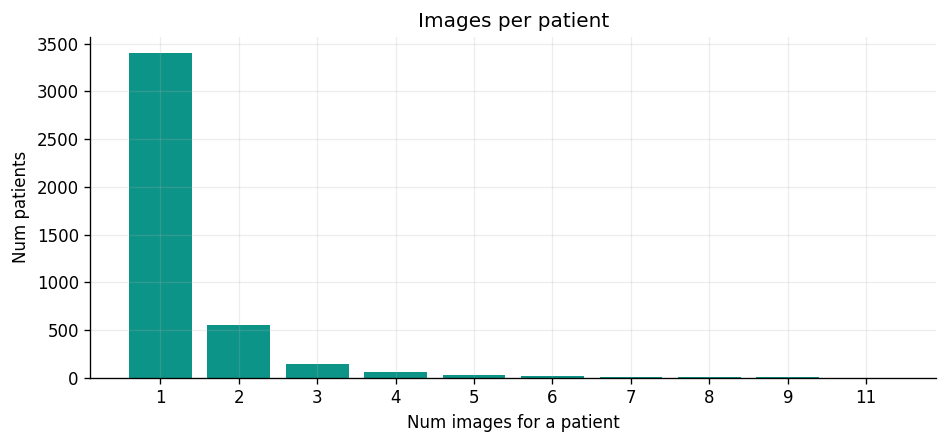

In [14]:
patient_visit_counts = df['Patient ID'].value_counts()
visit_dist = patient_visit_counts.value_counts().sort_index().to_frame('num_patients')
patient_overview = pd.DataFrame([
    ('unique_patients', df['Patient ID'].nunique()),
    ('mean_images_per_patient', patient_visit_counts.mean()),
    ('patients_with_more_than_one_image', int((patient_visit_counts > 1).sum())),
    ('max_images_for_one_patient', int(patient_visit_counts.max())),
], columns=['metric', 'value'])

display(patient_overview)
display(visit_dist)

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.bar(visit_dist.index.astype(str), visit_dist['num_patients'], color='#0d9488')
ax.set_title('Images per patient')
ax.set_xlabel('Num images for a patient')
ax.set_ylabel('Num patients')
plt.tight_layout()
plt.show()


In [15]:
patient_dynamics = compute_patient_dynamics(df)
display(patient_dynamics)


,metric,value
0,unique_patients,4230.000000
1,patients_with_multivisit,830.000000
2,stable_patients_same_labelset,217.000000
3,varied_patients,613.000000
4,nf_to_finding_patients,265.000000
5,finding_to_nf_patients,229.000000
6,both_direction_patients,92.000000
7,consecutive_visit_pairs,1376.000000
8,same_labelset_pair_ratio,0.282703
9,new_label_appears_pair_ratio,0.659884


patient_overlap                      overlap_ratio                               mean_abs_label_prev_drift                              
                        mean        std  min  max          mean       std       min       max                      mean       std       min       max
split_type                                                                                                                                           
image_random        335.3125  12.909219  305  369       0.32296  0.012139  0.292426  0.351094                  0.005763  0.001484  0.002152  0.011279
patient_wise          0.0000   0.000000    0    0       0.00000  0.000000  0.000000  0.000000                  0.006278  0.001426  0.002937  0.010751

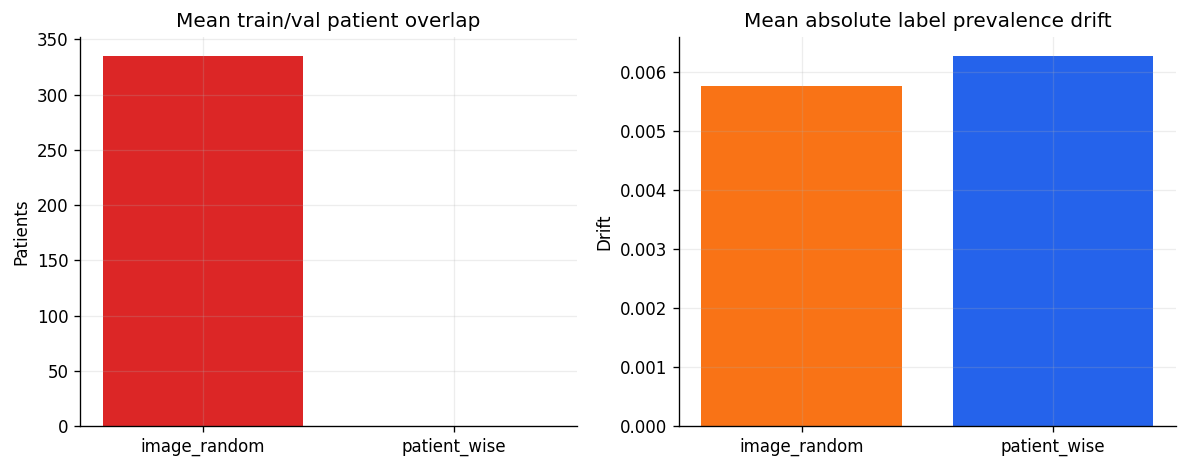

In [16]:
split_sim = simulate_split_leakage(df, multi_hot, repeats=80, seed=123)
split_summary = split_sim.groupby('split_type').agg(['mean', 'std', 'min', 'max'])
display(split_summary)

plot_df = split_summary.reset_index()
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(plot_df['split_type'], plot_df[('patient_overlap', 'mean')], color=['#dc2626', '#16a34a'])
axes[0].set_title('Mean train/val patient overlap')
axes[0].set_ylabel('Patients')
axes[1].bar(plot_df['split_type'], plot_df[('mean_abs_label_prev_drift', 'mean')], color=['#f97316', '#2563eb'])
axes[1].set_title('Mean absolute label prevalence drift')
axes[1].set_ylabel('Drift')
plt.tight_layout()
plt.show()


**Diễn giải:** Random split theo ảnh tạo overlap bệnh nhân đáng kể giữa train/validation, trong khi patient-wise split loại leakage mà drift label không tệ hơn đáng kể. Vì vậy split theo `Patient ID` là yêu cầu vận hành bắt buộc.


## 8. Image quality và cache

**Câu hỏi:** toàn bộ ảnh có format/kích thước/quality metric như thế nào, và cache image metrics có hoạt động không?


In [17]:
image_metrics, cache_status = compute_or_load_image_metrics(
    df['Image Index'].tolist(),
    paths.image_dir,
    paths.image_metrics_path,
    paths.image_metrics_meta_path,
    force=False,
)
df_img = df.merge(image_metrics, on='Image Index', how='left')

display(cache_status)


,metric,value
0,cache_hit,True
1,rows,5606
2,image_dir,/home/dodaonam/Projects/MedMAS/data/chest_x-ra...
3,metrics_path,/home/dodaonam/Projects/MedMAS/artifacts/eda_i...
4,meta_path,/home/dodaonam/Projects/MedMAS/artifacts/eda_i...


In [18]:
mode_summary = image_metrics['mode'].value_counts().to_frame('count')
size_summary = image_metrics.groupby(['width', 'height']).size().sort_values(ascending=False).to_frame('count')
rgba_summary = compute_rgba_consistency(image_metrics, paths.image_dir)

display(mode_summary)
display(size_summary)
display(rgba_summary)


,count
mode,
L,5583
RGBA,23


,,count
width,height,
1024,1024,5606


,metric,value
0,rgba_image_count,23
1,rgb_channels_identical_for_rgba,True
2,alpha_channel_constant_for_rgba,True


### 8.1 Kích thước thật của file ảnh đang load

**Câu hỏi:** các file ảnh PNG thực tế trên disk có kích thước bao nhiêu pixel khi load vào pipeline?


,width,height,count,size,share_pct
0,1024,1024,5606,1024x1024,100.0


mode,L,RGBA
row_0,,
1024x1024,5583,23


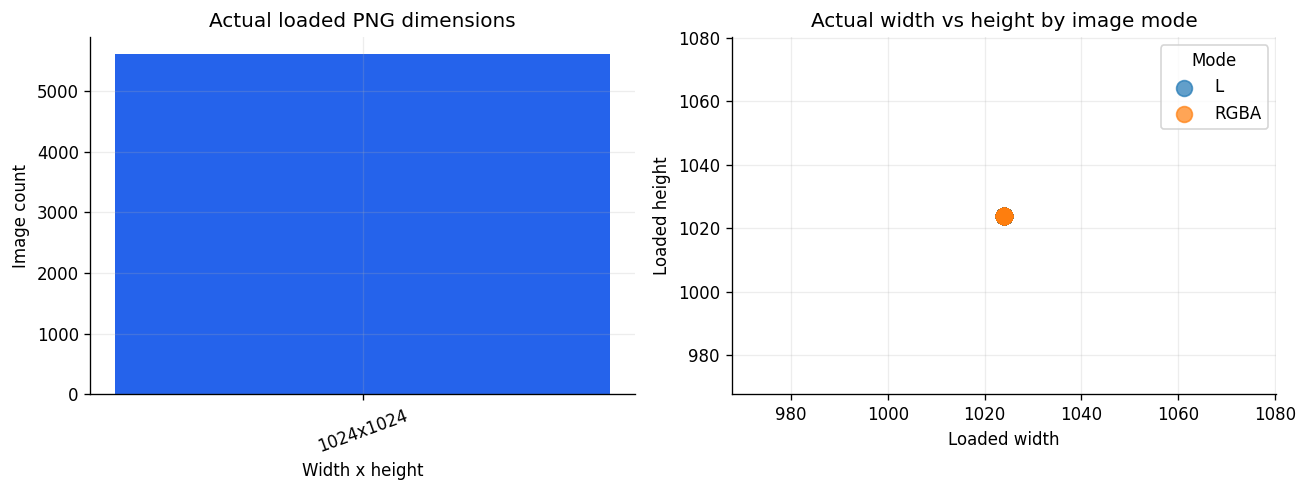

In [19]:
actual_size_summary = (
    image_metrics.groupby(['width', 'height'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)
actual_size_summary['size'] = actual_size_summary['width'].astype(str) + 'x' + actual_size_summary['height'].astype(str)
actual_size_summary['share_pct'] = actual_size_summary['count'] / len(image_metrics) * 100

actual_size_by_mode = pd.crosstab(
    image_metrics['width'].astype(str) + 'x' + image_metrics['height'].astype(str),
    image_metrics['mode'],
)

display(actual_size_summary)
display(actual_size_by_mode)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].bar(actual_size_summary['size'], actual_size_summary['count'], color='#2563eb')
axes[0].set_title('Actual loaded PNG dimensions')
axes[0].set_xlabel('Width x height')
axes[0].set_ylabel('Image count')
axes[0].tick_params(axis='x', rotation=20)

for mode, group in image_metrics.groupby('mode'):
    axes[1].scatter(group['width'], group['height'], s=90, alpha=0.7, label=mode)
axes[1].set_title('Actual width vs height by image mode')
axes[1].set_xlabel('Loaded width')
axes[1].set_ylabel('Loaded height')
axes[1].legend(title='Mode')
plt.tight_layout()
plt.show()


**Diễn giải:** Đây là kích thước thật của file PNG đang được notebook/pipeline load, không phải kích thước gốc trong metadata. Trong sample local, toàn bộ ảnh load ở 1024x1024, nên preprocessing/training có thể giả định input file hiện tại đồng nhất về spatial size; metadata gốc vẫn chỉ dùng để hiểu acquisition shift.


### 8.2 Mode ảnh và các kênh màu

**Câu hỏi:** ảnh local là grayscale hay nhiều kênh, và các ảnh RGBA có mang thêm thông tin màu/alpha thật không?


,mode,count,channel_count,share_pct
0,L,5583,1,99.589725
1,RGBA,23,4,0.410275


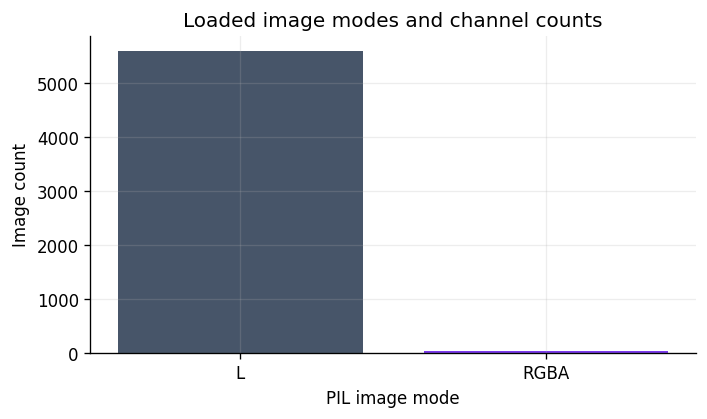

,image,channel,min,max,mean,std,unique_values
0,00000083_000.png,R,0.0,241.0,160.639373,45.998728,235
1,00000083_000.png,G,0.0,241.0,160.639373,45.998728,235
2,00000083_000.png,B,0.0,241.0,160.639373,45.998728,235
3,00000083_000.png,A,255.0,255.0,255.000000,0.000000,1


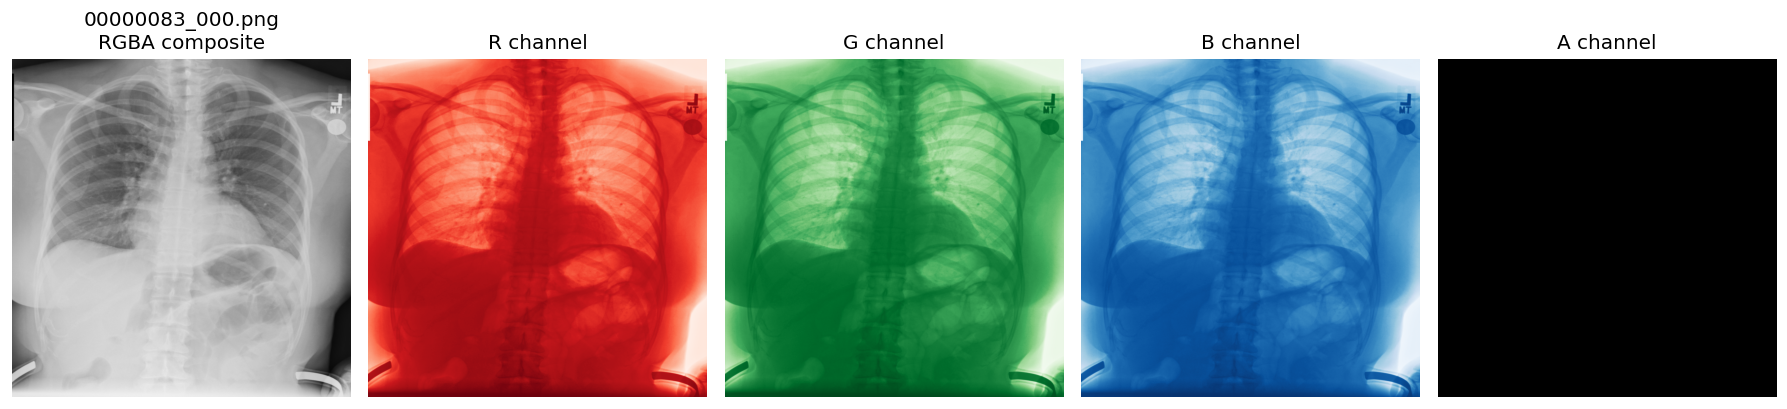

In [20]:
from PIL import Image

mode_channel_map = {'L': 1, 'RGB': 3, 'RGBA': 4}
mode_channel_summary = image_metrics['mode'].value_counts().rename_axis('mode').reset_index(name='count')
mode_channel_summary['channel_count'] = mode_channel_summary['mode'].map(mode_channel_map).fillna('unknown')
mode_channel_summary['share_pct'] = mode_channel_summary['count'] / len(image_metrics) * 100

display(mode_channel_summary)

fig, ax = plt.subplots(figsize=(6, 3.6))
ax.bar(mode_channel_summary['mode'], mode_channel_summary['count'], color=['#475569', '#7c3aed'][:len(mode_channel_summary)])
ax.set_title('Loaded image modes and channel counts')
ax.set_xlabel('PIL image mode')
ax.set_ylabel('Image count')
plt.tight_layout()
plt.show()

rgba_names = image_metrics.loc[image_metrics['mode'] == 'RGBA', 'Image Index'].tolist()
if rgba_names:
    rgba_name = rgba_names[0]
    rgba_arr = np.array(Image.open(paths.image_dir / rgba_name))
    channel_names = ['R', 'G', 'B', 'A']
    channel_stats = pd.DataFrame([
        {
            'image': rgba_name,
            'channel': channel,
            'min': float(rgba_arr[..., idx].min()),
            'max': float(rgba_arr[..., idx].max()),
            'mean': float(rgba_arr[..., idx].mean()),
            'std': float(rgba_arr[..., idx].std()),
            'unique_values': int(np.unique(rgba_arr[..., idx]).size),
        }
        for idx, channel in enumerate(channel_names)
    ])
    display(channel_stats)

    fig, axes = plt.subplots(1, 5, figsize=(15, 3.4))
    axes[0].imshow(rgba_arr)
    axes[0].set_title(f'{rgba_name}\nRGBA composite')
    axes[0].axis('off')
    cmaps = ['Reds', 'Greens', 'Blues', 'gray']
    for idx, (channel, cmap) in enumerate(zip(channel_names, cmaps), start=1):
        axes[idx].imshow(rgba_arr[..., idx - 1], cmap=cmap)
        axes[idx].set_title(f'{channel} channel')
        axes[idx].axis('off')
    plt.tight_layout()
    plt.show()
else:
    display(pd.DataFrame([('rgba_examples', 0)], columns=['metric', 'value']))


**Diễn giải:** Phần lớn ảnh là `L` grayscale. Các ảnh `RGBA` trong sample có RGB trùng nhau và alpha hằng số, nên có thể convert an toàn về single-channel cho training mà không mất tín hiệu màu thực chất.


,count,mean,std,min,1%,5%,50%,95%,99%,max
px_mean,5606.0,127.075987,22.366341,37.456024,81.420175,98.110544,122.271500,167.955624,179.053102,195.686035
px_std,5606.0,58.718194,10.864754,17.547073,30.595015,38.647853,60.533997,73.195517,77.578910,93.428291
p01_p99_contrast,5606.0,214.879058,24.206299,95.000000,138.050000,154.000000,223.000000,237.000000,243.000000,255.000000
pct_near_black,5606.0,0.032626,0.054743,0.000000,0.000000,0.000000,0.013978,0.116297,0.256083,0.664431
pct_near_white,5606.0,0.000290,0.000553,0.000000,0.000000,0.000000,0.000013,0.001137,0.002400,0.013013
entropy,5606.0,7.432953,0.365752,3.462518,6.315531,6.734353,7.506542,7.802774,7.844083,7.901265
sharpness_proxy,5606.0,42.065869,25.619615,3.266985,9.131661,12.284424,31.868905,94.021923,113.599709,172.056061


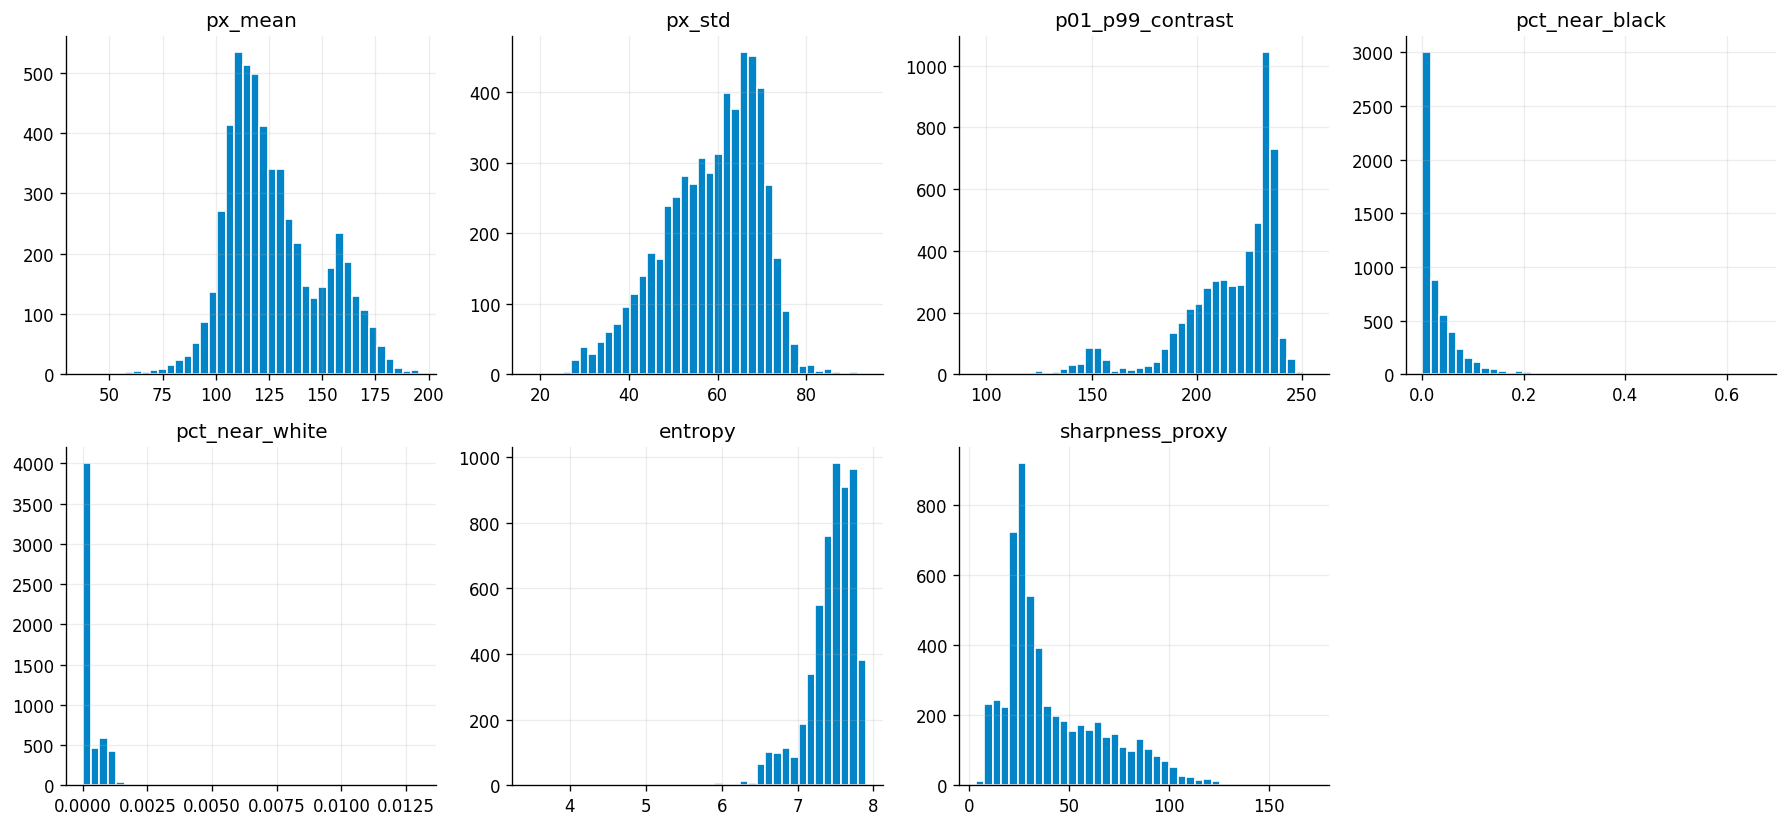

In [21]:
quality_summary = df_img[QUALITY_COLS].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T
display(quality_summary)

fig, axes = plt.subplots(2, 4, figsize=(15, 7))
for ax, col in zip(axes.ravel(), QUALITY_COLS):
    ax.hist(df_img[col], bins=40, color='#0284c7', edgecolor='white')
    ax.set_title(col)
axes.ravel()[-1].axis('off')
plt.tight_layout()
plt.show()


,px_mean,px_std,p01_p99_contrast,pct_near_black,pct_near_white,entropy,sharpness_proxy
View Position,,,,,,,
AP,124.004771,54.623094,207.269431,0.028605,0.000453,7.348358,59.798123
PA,129.079111,61.389121,219.842249,0.035248,0.000184,7.488129,30.500446


,px_mean,px_std,p01_p99_contrast,pct_near_black,pct_near_white,entropy,sharpness_proxy
Patient Gender,,,,,,,
F,124.851932,60.327102,214.711165,0.035412,0.000314,7.425846,42.099384
M,128.830251,57.449138,215.011487,0.030428,0.000271,7.438559,42.039433


,px_mean,px_std,p01_p99_contrast,pct_near_black,pct_near_white,entropy,sharpness_proxy
FindingGroup,,,,,,,
Has Finding,124.556523,58.934929,213.766393,0.034396,0.000299,7.426063,42.980772
No Finding,129.196508,58.535778,215.815539,0.031136,0.000282,7.438753,41.295835


,NumLabels
NumLabels,1.000000
sharpness_proxy,0.049235
pct_near_white,0.024607
px_std,0.014198
pct_near_black,0.008363
entropy,-0.008081
p01_p99_contrast,-0.030556
px_mean,-0.059951


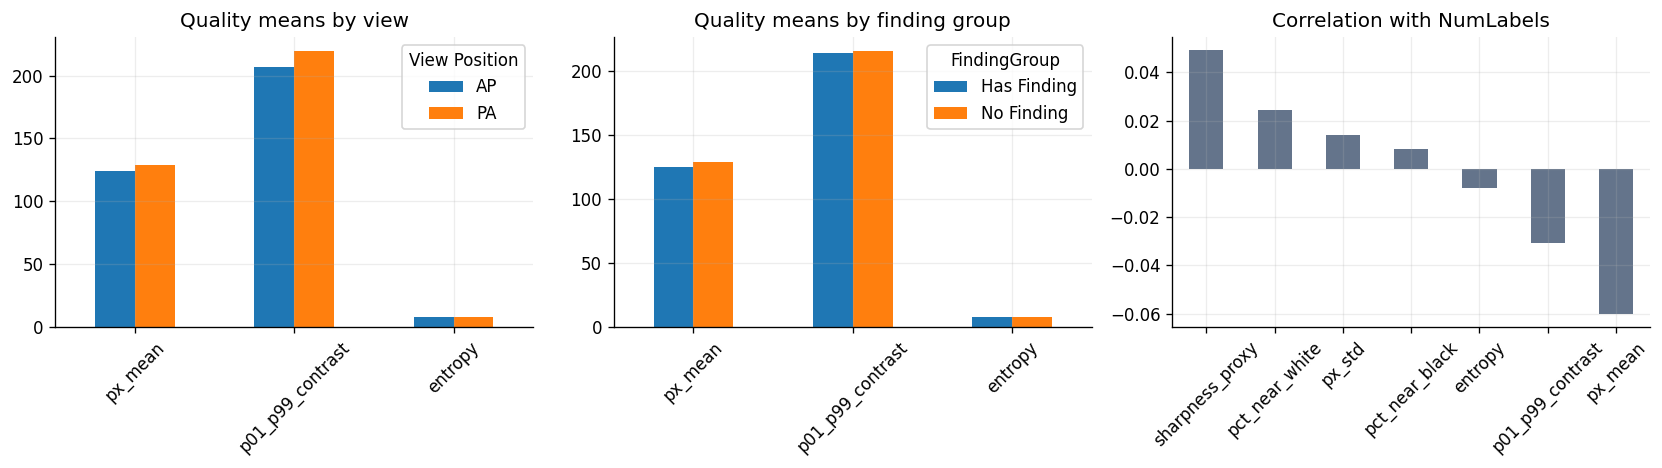

In [22]:
df_img['FindingGroup'] = np.where(df_img['Finding Labels'] == 'No Finding', 'No Finding', 'Has Finding')
quality_by_view = df_img.groupby('View Position')[QUALITY_COLS].mean()
quality_by_gender = df_img.groupby('Patient Gender')[QUALITY_COLS].mean()
quality_by_finding = df_img.groupby('FindingGroup')[QUALITY_COLS].mean()
quality_corr = df_img[['NumLabels'] + QUALITY_COLS].corr()[['NumLabels']].sort_values('NumLabels', ascending=False)

display(quality_by_view)
display(quality_by_gender)
display(quality_by_finding)
display(quality_corr)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
quality_by_view[['px_mean', 'p01_p99_contrast', 'entropy']].T.plot(kind='bar', ax=axes[0])
axes[0].set_title('Quality means by view')
quality_by_finding[['px_mean', 'p01_p99_contrast', 'entropy']].T.plot(kind='bar', ax=axes[1])
axes[1].set_title('Quality means by finding group')
quality_corr.drop(index='NumLabels').plot(kind='bar', ax=axes[2], legend=False, color='#64748b')
axes[2].set_title('Correlation with NumLabels')
for ax in axes:
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


**Diễn giải:** Ảnh đều load-ready ở kích thước 1024x1024, nhưng có heterogeneity rõ về dynamic range, entropy, black border và sharpness proxy. AP/PA cũng khác nhau về quality trung bình, nên quality/acquisition có thể là nguồn confounding độc lập.


## 9. Outlier và near-duplicate candidates

**Câu hỏi:** ảnh nào có quality metric bất thường, và aHash có gợi ý nhóm ảnh rất giống nhau không?


,Image Index,Finding Labels,Patient ID,View Position,max_abs_z_quality,px_mean,px_std,p01_p99_contrast,pct_near_black,pct_near_white,entropy,sharpness_proxy
4724,00024300_000.png,No Finding,24300,PA,23.020564,114.977676,64.847107,255.0,0.023006,0.013013,7.787002,83.625412
2785,00013924_003.png,Pneumothorax,13924,PA,15.892338,118.559494,62.348007,248.0,0.007088,0.009073,7.844796,41.935936
2198,00011379_024.png,Pleural_Thickening|Pneumothorax,11379,PA,15.297025,90.046509,68.694481,251.0,0.043413,0.008744,7.516514,42.387749
5203,00027765_000.png,Infiltration,27765,AP,11.542257,41.294495,67.127426,199.0,0.664431,0.000755,3.462518,72.388161
4059,00020008_001.png,No Finding,20008,AP,11.306079,47.648476,71.806572,208.0,0.651503,0.000043,3.530260,68.213394
2998,00014751_000.png,Effusion|Mass,14751,PA,10.953828,122.292549,69.387260,241.0,0.031054,0.006344,7.807709,74.888565
5355,00028879_000.png,No Finding,28879,PA,10.761559,37.456024,58.412483,192.0,0.621696,0.000038,3.858056,44.474487
5401,00029174_003.png,Infiltration,29174,AP,9.902391,58.601551,77.120605,219.0,0.574667,0.000528,4.193957,49.500355
4372,00021586_003.png,No Finding,21586,PA,9.783909,109.355469,60.090813,236.0,0.005715,0.005697,7.811784,39.054947
1432,00007438_000.png,No Finding,7438,AP,9.679576,65.240799,81.407471,216.0,0.562470,0.000000,4.208519,46.528858


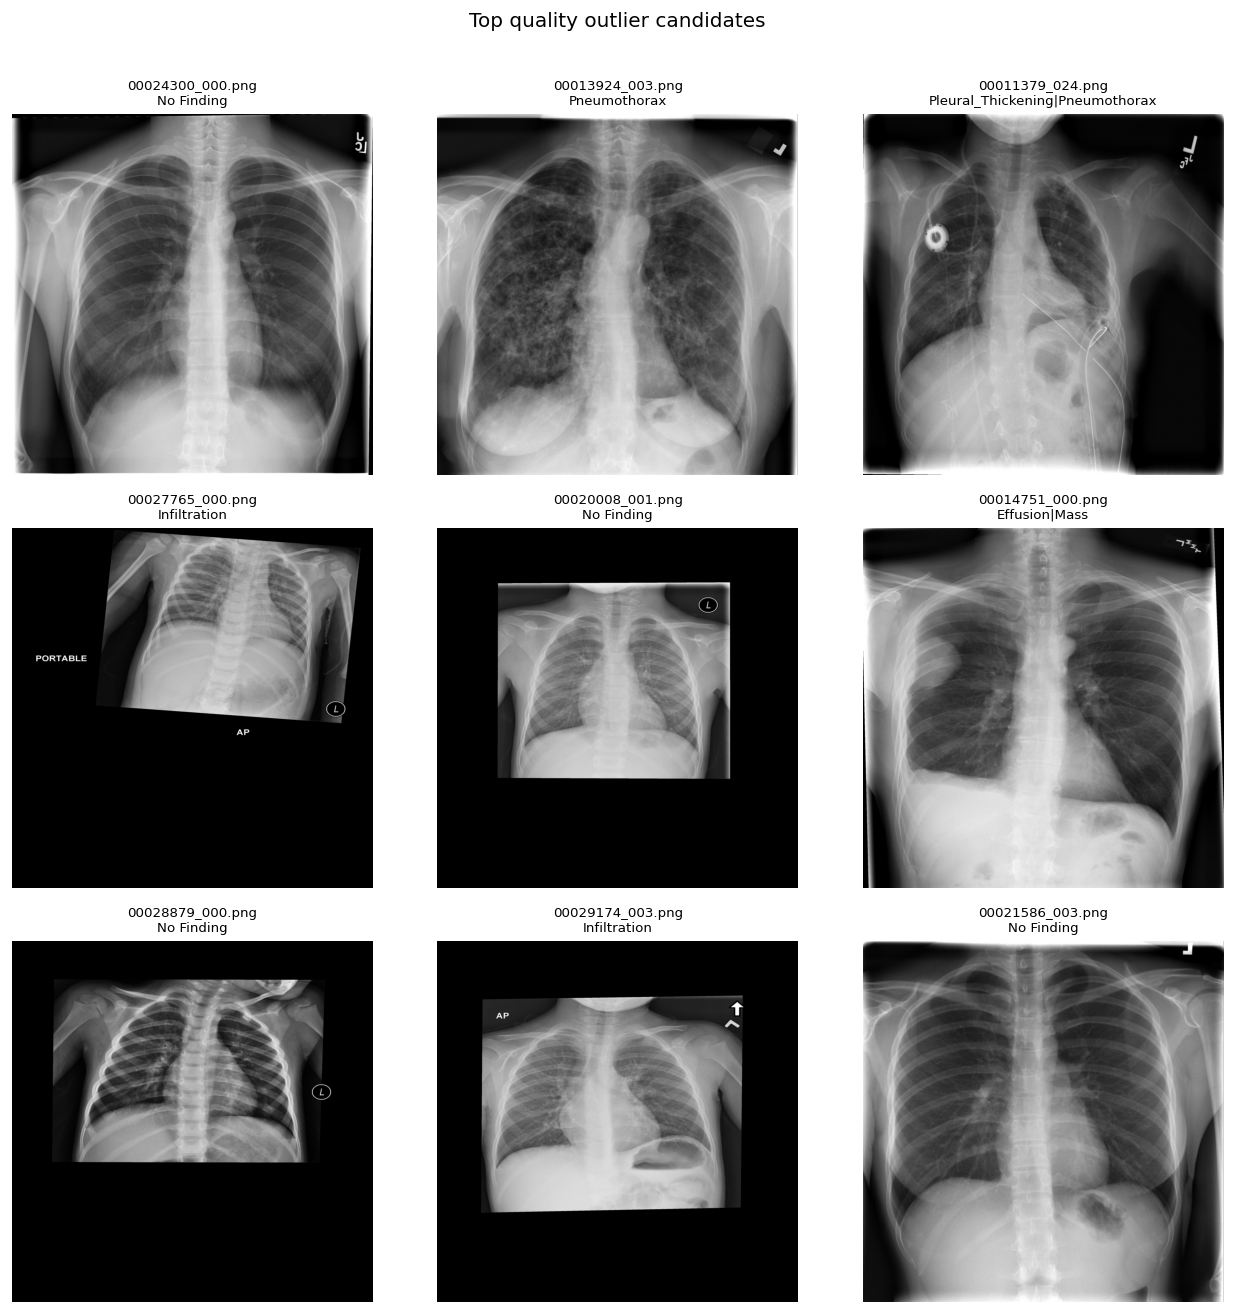

In [23]:
z = (df_img[QUALITY_COLS] - df_img[QUALITY_COLS].mean()) / df_img[QUALITY_COLS].std(ddof=0)
df_img['max_abs_z_quality'] = z.abs().max(axis=1)
outliers = df_img.sort_values('max_abs_z_quality', ascending=False).head(12)

display(outliers[['Image Index', 'Finding Labels', 'Patient ID', 'View Position', 'max_abs_z_quality'] + QUALITY_COLS])
plot_image_grid(outliers.head(9), paths.image_dir, ['Image Index', 'Finding Labels'], n_cols=3, suptitle='Top quality outlier candidates')
plt.show()


,metric,value
0,collision_groups,41
1,images_in_collision_groups,87
2,pairs_same_patient_id,2
3,pairs_cross_patient_id,49
4,pairs_same_labelset,14
5,pairs_cross_labelset,37


,CollisionGroup,Image Index,Patient ID,FollowUpNum,Finding Labels
1130,1,00005916_004.png,5916,4,Atelectasis|Consolidation|Infiltration
1935,1,00010092_036.png,10092,36,Infiltration|Mass
3702,1,00018175_026.png,18175,26,Atelectasis
2207,2,00011391_013.png,11391,13,Infiltration
2208,2,00011391_044.png,11391,44,Edema|Infiltration
3421,2,00016867_005.png,16867,5,Atelectasis
2013,3,00010481_021.png,10481,21,Atelectasis
2213,3,00011402_016.png,11402,16,No Finding
4786,3,00025163_000.png,25163,0,No Finding


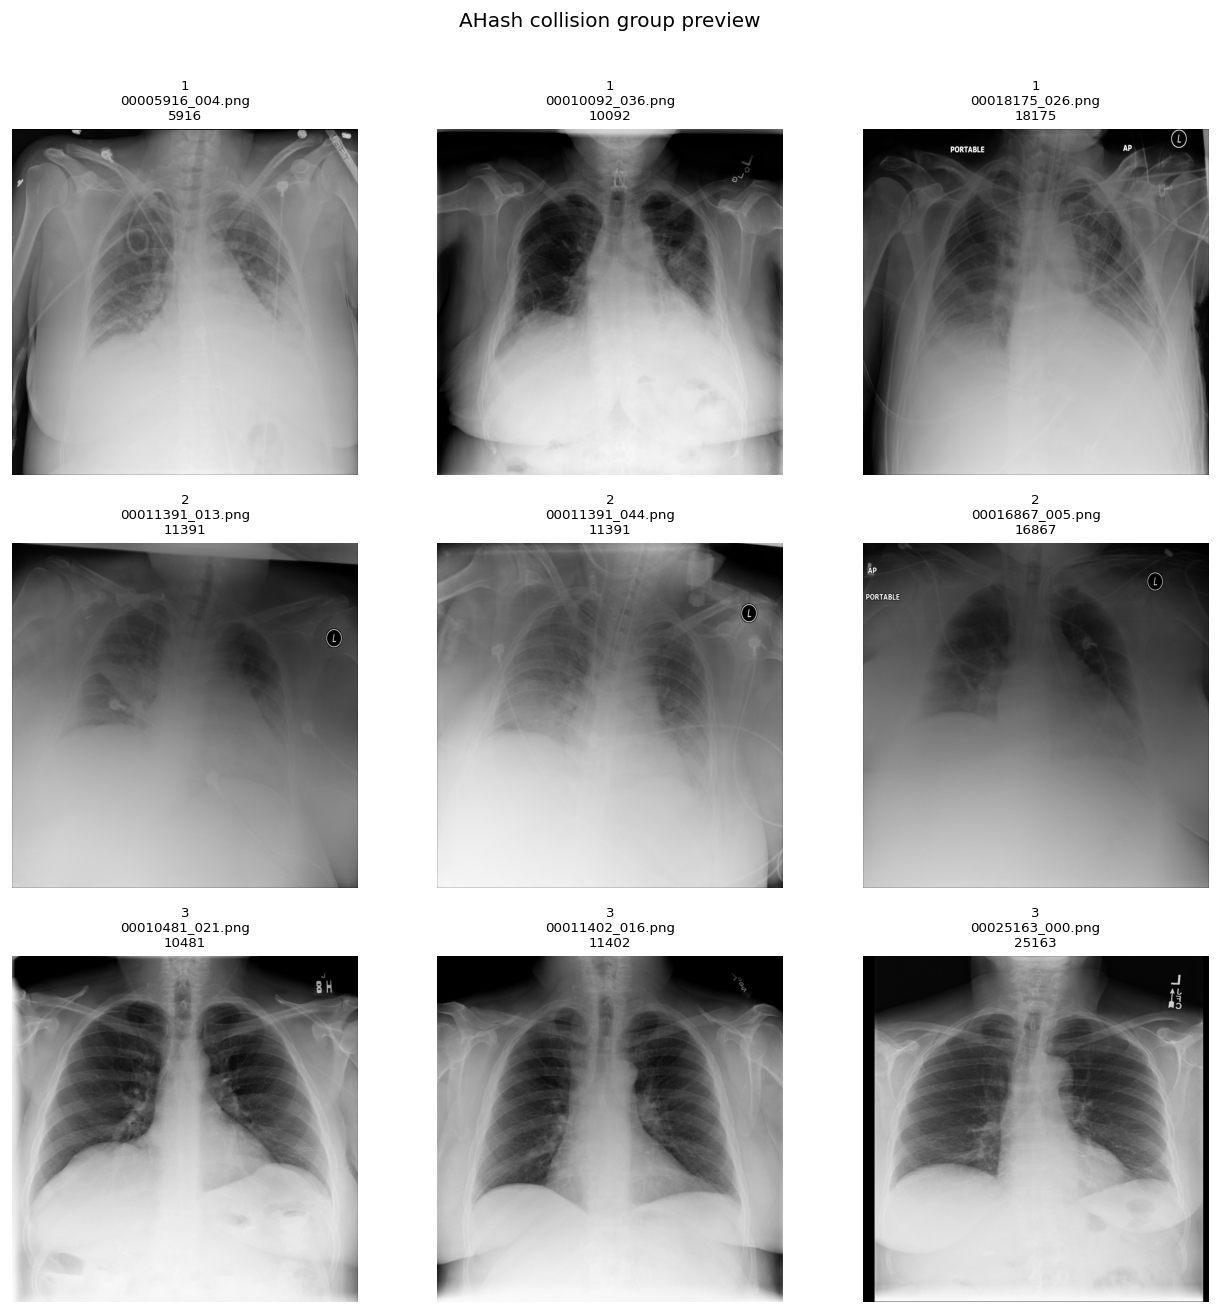

In [24]:
ahash_summary, collision_groups = summarize_ahash_collisions(image_metrics, df_img)
display(ahash_summary)

if collision_groups:
    rows = []
    for group_idx, group in enumerate(collision_groups[:3], start=1):
        for name in group:
            row = df_img.loc[df_img['Image Index'] == name].iloc[0].copy()
            row['CollisionGroup'] = group_idx
            rows.append(row)
    collision_preview = pd.DataFrame(rows)
    display(collision_preview[['CollisionGroup', 'Image Index', 'Patient ID', 'FollowUpNum', 'Finding Labels']])
    plot_image_grid(collision_preview, paths.image_dir, ['CollisionGroup', 'Image Index', 'Patient ID'], n_cols=max(len(g) for g in collision_groups[:3]), suptitle='AHash collision group preview')
    plt.show()
else:
    display(pd.DataFrame([('collision_groups', 0)], columns=['metric', 'value']))


**Diễn giải:** Quality outliers và aHash collisions là tín hiệu QA cần xem xét, không phải bằng chứng tự động để loại ảnh. aHash collision chỉ nói ảnh rất giống theo hash đơn giản, không khẳng định duplicate thật.


## 10. Modeling recommendations

**Câu hỏi:** các insight EDA dẫn tới quyết định modeling/evaluation nào?


In [25]:
recommendations = pd.DataFrame([
    ('Patient leakage', 'Section 7 split simulation', 'Use patient-wise/group split by Patient ID'),
    ('Class imbalance', 'Section 4 label frequency', 'Report per-class AUROC/PR-AUC and use weighted BCE or focal loss'),
    ('Rare labels', 'Section 4 rare-label table', 'Tune thresholds per class and inspect rare-class PR curves'),
    ('AP/PA confounding', 'Section 6 AP/PA risk ratio', 'Evaluate AP and PA subgroups separately'),
    ('Age metadata outlier', 'Section 3 age outlier table', 'Clip/winsorize or guard age metadata before model use'),
    ('Image quality heterogeneity', 'Section 8 quality metrics', 'Normalize robustly and consider black-border/foreground preprocessing'),
    ('Near-duplicate candidates', 'Section 9 aHash summary', 'Treat as QA signal and inspect overfitting risk'),
], columns=['risk', 'evidence_output', 'modeling_action'])
display(recommendations)


,risk,evidence_output,modeling_action
0,Patient leakage,Section 7 split simulation,Use patient-wise/group split by Patient ID
1,Class imbalance,Section 4 label frequency,Report per-class AUROC/PR-AUC and use weighted...
2,Rare labels,Section 4 rare-label table,Tune thresholds per class and inspect rare-cla...
3,AP/PA confounding,Section 6 AP/PA risk ratio,Evaluate AP and PA subgroups separately
4,Age metadata outlier,Section 3 age outlier table,Clip/winsorize or guard age metadata before mo...
5,Image quality heterogeneity,Section 8 quality metrics,Normalize robustly and consider black-border/f...
6,Near-duplicate candidates,Section 9 aHash summary,Treat as QA signal and inspect overfitting risk


**Kết luận:** Sample local đủ sạch để xây pipeline nghiên cứu, nhưng kết quả model chỉ đáng tin nếu xử lý đúng bốn rủi ro chính: imbalance, patient leakage, AP/PA acquisition confounding, và image-quality heterogeneity.
